<div style="background-color:#e3f2fd; padding:15px; border-radius:10px;">
  <h1 style="margin-bottom:5px;">The Cardio Performance Analysis</h1>
  <p>
    This notebook is about exploring customer data to understand things like income, usage, and overall performance patterns.  
    I’ll go through different parts step by step and try to get some useful insights from the data.
  </p>
</div>

<div style="background-color:#e8f5e9; padding:12px; border-radius:10px;">
  <h3>objectives</h3>
  <ul>
    <li>how income looks like across customers and if there is any gap</li>
    <li>how things like age and usage are distributed</li>
    <li>if there is any relation between usage and miles</li>
    <li>and also see what kind of customers have high fitness scores</li>
  </ul>
</div>

### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### loading the data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/estifanosandualem/cardio-performance-analysis/dataset-1.csv')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


### checking the data

checking the columns, data types and if there are missing values

In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


<div style="background-color:#f3e5f5; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">income distribution</h3>
</div>

here I tried to understand how income is spread across customers.  
so I calculated the mean, median and mode to get a general idea.

In [4]:
# basic stats for income
mean_income = df['Income'].mean()
median_income = df['Income'].median()
mode_income = df['Income'].mode()[0]

print("mean:", mean_income)
print("median:", median_income)
print("mode:", mode_income)

mean: 53719.57777777778
median: 50596.5
mode: 45480


<div style="background-color:#fff3e0; padding:10px; border-left:5px solid orange; border-radius:6px;">
<b>After i compared the mean and the Median to see the data is skewed</b> the mean is a bit higher than the median, so a few high earners push the average up.  
the median probably shows a better idea of what a normal customer earns.
</div>

<div style="background-color:#e0f7fa; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">miles overview</h3>
</div>



here I looked at the miles column to understand how it is distributed.  
I used the 5-number summary (min, Q1, median, Q3, max).

In [5]:
# 5 number summary 
df['Miles'].describe()[['min','25%','50%','75%','max']]

min     21.00
25%     66.00
50%     94.00
75%    114.75
max    360.00
Name: Miles, dtype: float64

<div style="background-color:#e0f7fa; padding:10px; border-left:5px solid #039be5; border-radius:6px;">
<b>my observation:</b> the data shows the min, quartiles, median, and max.  
this gives a good idea about spread and where most values sit.
</div>

To make it easier to see, I used a boxplot.

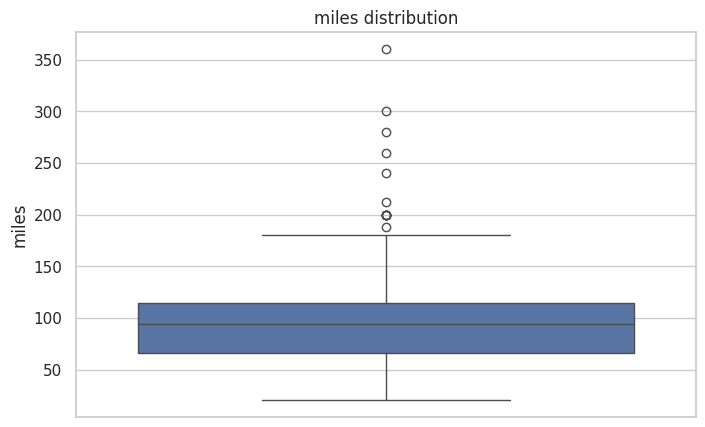

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Miles'])

plt.title('miles distribution')
plt.ylabel('miles')

plt.show()

<div style="background-color:#e0f7fa; padding:10px; border-left:5px solid #039be5; border-radius:6px;">
some points fall outside the whiskers, so these are outliers in miles.
</div>

<div style="background-color:#ffebee; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">age distribution</h3>
</div>

here I wanted to see how ages are spread out.  
I used a histogram with 10 bins.

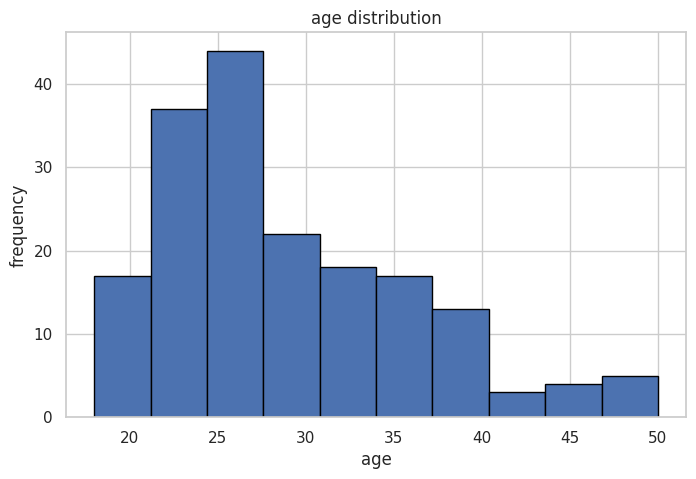

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10, edgecolor='black')
plt.title('age distribution')
plt.xlabel('age')
plt.ylabel('frequency')
plt.show()

<div style="background-color:#ffebee; padding:10px; border-left:5px solid #e53935; border-radius:6px;">
 The median seems to fall in the bin around 25-30 years. that’s where most customers are.
</div>

<div style="background-color:#fff9c4; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">product popularity</h3>
</div>

here I wanted to see which products are bought the most by customers.  
so I made a simple count plot for each product type.

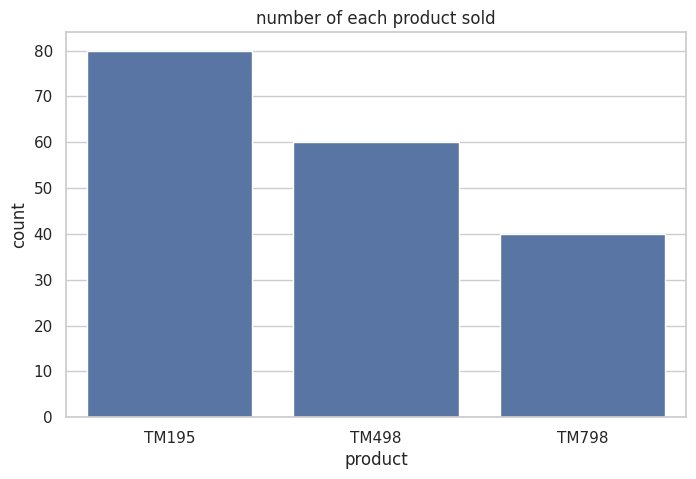

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Product', data=df, order=['TM195','TM498','TM798'])
plt.title('number of each product sold')
plt.xlabel('product')
plt.ylabel('count')
plt.show()

<div style="background-color:#fff9c4; padding:10px; border-left:5px solid #fbc02d; border-radius:6px;">
It looks like some products are much more popular than others.  
TM195 seems to have the most buyers.
</div>

<div style="background-color:#e0f2f1; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">income vs product</h3>
</div>

Next I wanted to see if some products are mostly bought by higher-income customers.  
so I compared income across the three product types using a boxplot.

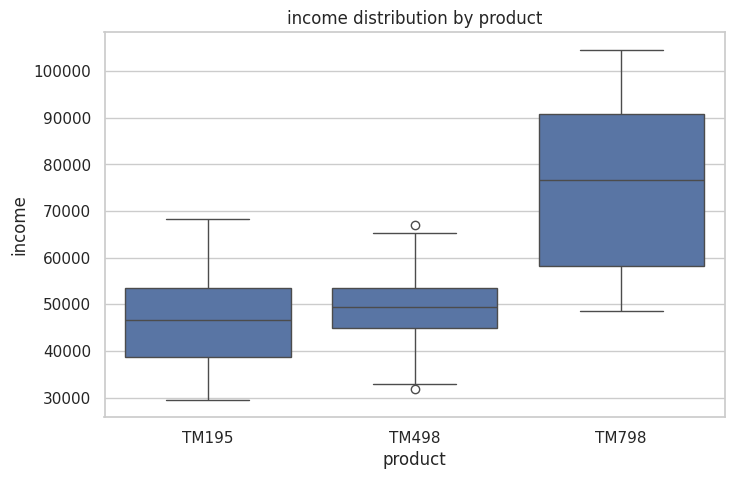

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Product', y='Income', data=df, order=['TM195','TM498','TM798'])
plt.title('income distribution by product')
plt.xlabel('product')
plt.ylabel('income')
plt.show()

<div style="background-color:#e0f2f1; padding:10px; border-left:5px solid #00796b; border-radius:6px;">
TM798 seems to be clearly targeted at high-income customers since its box is much higher than the others.  
TM195 is more for average earners.
</div>



<div style="background-color:#fce4ec; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">Gender probability for TM195</h3>
</div>

here I wanted to see the chance that a customer is female if they bought TM195.  
so I filtered the data for TM195 and calculated the probability.

In [10]:
# filter TM195 buyers
tm195_df = df[df['Product']=='TM195']

# number of females who bought TM195
female_count = tm195_df[tm195_df['Gender']=='Female'].shape[0]

# total TM195 buyers
total_tm195 = tm195_df.shape[0]

# probability
prob_female_tm195 = female_count / total_tm195

print("probability that a customer is female given TM195:", prob_female_tm195)

probability that a customer is female given TM195: 0.5


<div style="background-color:#fce4ec; padding:10px; border-left:5px solid #d81b60; border-radius:6px;">
<b>what i noticed is </b> the probability shows how likely a TM195 buyer is female.  
from this, we can see which gender mostly buys this product.
</div>

<div style="background-color:#ede7f6; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">correlation heatmap</h3>
</div>

here I wanted to see how the numerical variables relate to each other, especially which ones are linked with miles.

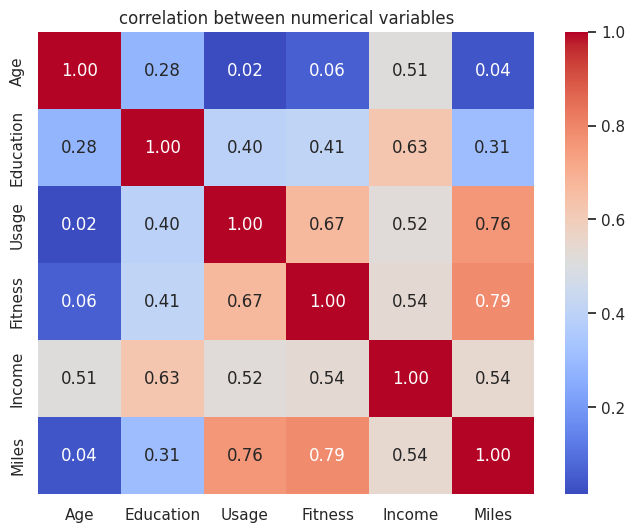

In [11]:
plt.figure(figsize=(8,6))

# use only numeric columns
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('correlation between numerical variables')

plt.show()

<div style="background-color:#ede7f6; padding:10px; border-left:5px solid #5e35b1; border-radius:6px;">
 Among Age, Education, and Usage, Usage has the strongest positive correlation with Miles.  
so customers who use more tend to travel more miles.
</div>

<div style="background-color:#e1f5fe; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">usage vs miles scatter plot</h3>
</div>

to visualize the relationship between usage and miles, I plotted a scatter plot and added a regression line.

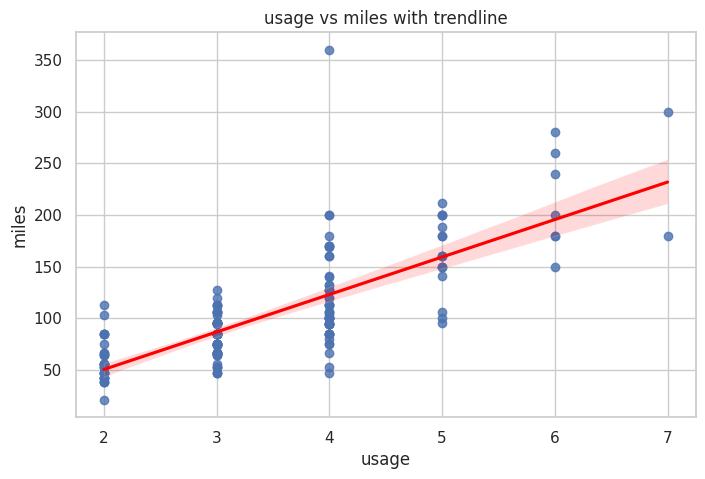

In [12]:
plt.figure(figsize=(8,5))
sns.regplot(x='Usage', y='Miles', data=df, line_kws={"color":"red"})
plt.title('usage vs miles with trendline')
plt.xlabel('usage')
plt.ylabel('miles')
plt.show()

<div style="background-color:#e1f5fe; padding:10px; border-left:5px solid #039be5; border-radius:6px;">
The trendline confirms that higher usage tends to result in more miles.  
this could be useful for predicting future behavior.
</div>

<div style="background-color:#f1f8e9; padding:10px; border-radius:8px;">
  <h3 style="margin:0;">elite customer profile</h3>
</div>

here I created a subset of customers with a fitness score of 5 to see what their “average profile” looks like.

In [13]:
elite_df = df[df['Fitness']==5]

avg_age = elite_df['Age'].mean()
avg_edu = elite_df['Education'].mean()
avg_income = elite_df['Income'].mean()

print("Average Age:", avg_age)
print("Average Education:", avg_edu)
print("Average Income:", avg_income)

Average Age: 29.806451612903224
Average Education: 17.06451612903226
Average Income: 74396.70967741935


<div style="background-color:#f1f8e9; padding:10px; border-left:5px solid #689f38; border-radius:6px;">
<b>In General</b> elite customers are on average around 30 years old, with about 17 years of education and an income around 74000.  
this suggests that higher fitness levels are more common among relatively young and moderately well-educated customers with stable income.
</div>